# Load Data

In [1]:
import pandas as pd
import random
import time
from tqdm import tqdm

df = pd.read_parquet("../data/processed/housing_clean.parquet")
print(df)

             Precio                                             Título  \
0      4.197285e+08  ZOLEA GOLDEN LIVING, Apartaestudios en Venta e...   
1      2.090000e+08  ANDINO APARTAMENTOS, Apartaestudios en Venta e...   
2      3.900000e+08                  Apartaestudio en Venta en Armenia   
3      1.410000e+08       Apartaestudio en Venta en Oro Negro, Armenia   
4      1.450000e+08                  Apartaestudio en venta en Armenia   
...             ...                                                ...   
60498  1.900000e+09                             Lote en  Venta en Chía   
60499  6.500000e+07        Lote en  Venta en Paso de la bolsa, Jamundí   
60500  1.300000e+08                      Lote en Venta en Sur, Jamundí   
60501  3.750000e+08                Lote en venta en La Morada, Jamundí   
60502  1.998000e+09                Lote en venta en Arroyohondo, Yumbo   

                                             URL detalle  \
0      https://www.fincaraiz.com.co/proyectos-vivie

In [6]:
print(df.columns)

Index(['Precio', 'Título', 'URL detalle', 'Descripción breve',
       'Descripción completa', 'Publicante', 'Habitaciones', 'Baños',
       'Area_m2', 'Tipo_propiedad', 'Ciudad', 'Departamento', 'Barrio',
       'Etiqueta_Proyecto', 'Etiqueta_Destacado', 'Etiqueta_Nuevo',
       'Etiqueta_Oportunidad', 'Latitud', 'Longitud'],
      dtype='object')


In [8]:
print(df.describe())

             Precio  Habitaciones         Baños       Area_m2  \
count  6.050300e+04  60503.000000  60503.000000  6.050300e+04   
mean   2.036205e+09      3.057353      3.114242  8.169804e+03   
std    4.838172e+10      2.001070      1.970831  5.389204e+05   
min    1.147000e+05      0.000000      0.000000  1.000000e-03   
25%    3.100000e+08      2.000000      2.000000  6.700000e+01   
50%    5.450000e+08      3.000000      3.000000  1.220000e+02   
75%    1.100000e+09      4.000000      4.000000  2.720000e+02   
max    6.000000e+12     82.000000     82.000000  7.500000e+07   

       Etiqueta_Proyecto  Etiqueta_Destacado  Etiqueta_Nuevo  \
count       60503.000000        60503.000000         60503.0   
mean            0.013057            0.059716             0.0   
std             0.113521            0.236962             0.0   
min             0.000000            0.000000             0.0   
25%             0.000000            0.000000             0.0   
50%             0.000000      

In [2]:
print(df.head().to_string())

        Precio                                                             Título                                                                                                               URL detalle                                                  Descripción breve                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [38]:

# -------------------------------------------------------------------------
# 0. IMPORTS
# -------------------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy import sparse
import joblib

# -------------------------------------------------------------------------
# 1. STOP-WORDS EN ESPAÑOL (opcional, usando nltk)
# -------------------------------------------------------------------------
def get_spanish_stopwords():
    """Devuelve lista de stop-words en español o None si no está disponible."""
    try:
        import nltk
        from nltk.corpus import stopwords

        try:                     # por si aún no se han descargado
            nltk.data.find("corpora/stopwords")
        except LookupError:
            nltk.download("stopwords", quiet=True)

        return stopwords.words("spanish")
    except Exception as e:
        print("⚠️  No se pudo cargar stop-words en español → sin filtrado.", e)
        return None

spanish_stop = get_spanish_stopwords()

# -------------------------------------------------------------------------
# 2. CARGA Y ORGANIZACIÓN DE COLUMNAS
# -------------------------------------------------------------------------
df_full = pd.read_parquet("../data/processed/housing_clean.parquet")

numeric_base   = ["Habitaciones", "Baños", "Area_m2", "Latitud", "Longitud"]
binary_vars    = ["Etiqueta_Proyecto", "Etiqueta_Destacado", "Etiqueta_Oportunidad"]
service_cols   = [c for c in df_full.columns if c.startswith("n_")]
numeric_feats  = numeric_base + binary_vars + service_cols

categorical_feats = ["Publicante", "Tipo_propiedad",
                     "Ciudad", "Departamento", "Barrio"]

df_full["texto"] = (
    df_full["Título"].fillna("")
    + " " + df_full["Descripción breve"].fillna("")
    + " " + df_full["Descripción completa"].fillna("")
)
text_feat = "texto"

y = np.log1p(df_full["Precio"].astype(float))   # objetivo

# -------------------------------------------------------------------------
# 3. TRANSFORMERS
# -------------------------------------------------------------------------
numeric_t = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_t = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

text_t = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        stop_words=spanish_stop      # ← lista o None
    )),
    ("svd",   TruncatedSVD(n_components=256, random_state=42))
])

preprocessor = ColumnTransformer([
    ("num", numeric_t,      numeric_feats),
    ("cat", categorical_t,  categorical_feats),
    ("txt", text_t,         text_feat)
], remainder="drop", sparse_threshold=0.3)

# -------------------------------------------------------------------------
# 4. SPLIT, AJUSTE Y TRANSFORMACIÓN
# -------------------------------------------------------------------------
X = df_full[numeric_feats + categorical_feats + [text_feat]]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep   = preprocessor.transform(X_val)

print("Shapes:", X_train_prep.shape, X_val_prep.shape)

# -------------------------------------------------------------------------
# 5. GUARDADO (opcional)
# -------------------------------------------------------------------------
# sparse.save_npz("data/interim/X_train.npz", X_train_prep)
# sparse.save_npz("data/interim/X_val.npz",   X_val_prep)
## np.savez("data/interim/y_train_val.npz", y_train=y_train, y_val=y_val)
# joblib.dump(preprocessor, "models/preprocessor.joblib")

print("✅  Pipeline listo: usa X_train_prep / y_train para entrenar y valida con X_val_prep / y_val.")


Shapes: (48402, 7072) (12101, 7072)
✅  Pipeline listo: usa X_train_prep / y_train para entrenar y valida con X_val_prep / y_val.


In [26]:
# ---------------------------------------------------------------------
# 0. IMPORTS & HELPERS
# ---------------------------------------------------------------------
import numpy as np
import joblib
from scipy import sparse
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Solo se importan si están instalados
import lightgbm as lgb
from xgboost import XGBRegressor

In [39]:
# ---------------------------------------------------------------------
# 1. LOAD PREPARED MATRICES
# ---------------------------------------------------------------------
X_train = X_train_prep          # ya creados en el paso de pre-procesado
X_val   = X_val_prep

y_train_log = y_train           # log1p(Precio) original
y_val_log   = y_val

# ---------------------------------------------------------------------
# 1.1 WINSORIZAR OBJETIVO
#     — se calcula sobre el train y se aplica al val —
# ---------------------------------------------------------------------
y_train_eur = np.expm1(y_train_log)
y_val_eur   = np.expm1(y_val_log)

p_low, p_high = np.percentile(y_train_eur, [0.5, 99])

y_train_eur_clip = np.clip(y_train_eur, p_low, p_high)
y_val_eur_clip   = np.clip(y_val_eur,   p_low, p_high)

y_train = np.log1p(y_train_eur_clip)   # nuevo objetivo clip-log
y_val   = np.log1p(y_val_eur_clip)

print(f"Winsorizado target entre {p_low:,.0f} y {p_high:,.0f} COP")

Winsorizado target entre 92,503,551 y 8,100,000,000 COP


In [40]:

# ---------------------------------------------------------------------
# 2. SCORING FUNCTION
# ---------------------------------------------------------------------
def score_model(model, X_tr, y_tr, X_v, y_v, name="model"):
    model.fit(X_tr, y_tr)
    pred_v_log = model.predict(X_v)

    # Métricas en log
    rmse_log = mean_squared_error(y_v, pred_v_log, squared=False)
    mae_log  = mean_absolute_error(y_v, pred_v_log)
    r2_log   = r2_score(y_v, pred_v_log)

    # Métricas en euros (ya winsorizados)
    pred_v_eur = np.expm1(pred_v_log)
    rmse_eur = mean_squared_error(y_val_eur_clip, pred_v_eur, squared=False)
    mae_eur  = mean_absolute_error(y_val_eur_clip, pred_v_eur)
    r2_eur   = r2_score(y_val_eur_clip, pred_v_eur)

    print(f"🔹 {name}: RMSE$={rmse_eur:,.0f} | MAE$={mae_eur:,.0f} | "
          f"R²$={r2_eur:0.3f}  (log-RMSE={rmse_log:0.3f})")

    return {
        "name": name, "model": model,
        "rmse_eur": rmse_eur, "mae_eur": mae_eur, "r2_eur": r2_eur,
        "rmse_log": rmse_log
    }

results = []

# ---------------------------------------------------------------------
# 3. RIDGE BASELINE
# ---------------------------------------------------------------------
print("≡ Entrenando Ridge…")
ridge = Ridge(alpha=1.0, random_state=42)
results.append(score_model(ridge, X_train, y_train, X_val, y_val, "Ridge"))

# ---------------------------------------------------------------------
# 4. LIGHTGBM
# ---------------------------------------------------------------------
if lgb is not None:
    print("\n≡ Entrenando LightGBM…")
    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": 1500,
        "learning_rate": 0.05,
        "num_leaves": 128,
        "feature_fraction": 0.8,
        "subsample": 0.8,
        "random_state": 42,
    }
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    results.append(score_model(lgb_model, X_train, y_train, X_val, y_val, "LightGBM"))
else:
    print("⚠️  LightGBM no instalado; saltando.")

# ---------------------------------------------------------------------
# 5. XGBOOST
# ---------------------------------------------------------------------
if XGBRegressor is not None:
    print("\n≡ Entrenando XGBoost…")
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist"
    )
    results.append(score_model(xgb_model, X_train, y_train, X_val, y_val, "XGBoost"))
else:
    print("⚠️  XGBoost no instalado; saltando.")


≡ Entrenando Ridge…


c:\Users\Julian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\Julian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


🔹 Ridge: RMSE€=974,521,114 | MAE€=419,224,311 | R²€=0.445  (log-RMSE=0.522)

≡ Entrenando LightGBM…
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.320385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 68084
[LightGBM] [Info] Number of data points in the train set: 48402, number of used features: 1255
[LightGBM] [Info] Start training from score 20.226373
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


c:\Users\Julian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\Julian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


🔹 LightGBM: RMSE€=776,296,981 | MAE€=305,235,440 | R²€=0.648  (log-RMSE=0.383)

≡ Entrenando XGBoost…
🔹 XGBoost: RMSE€=778,475,091 | MAE€=306,664,464 | R²€=0.646  (log-RMSE=0.384)


c:\Users\Julian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\Julian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [1]:
print(df_full['Precio'].head())

NameError: name 'df_full' is not defined

Text(0.5, 1.0, 'Distribución log(Precio+1)')

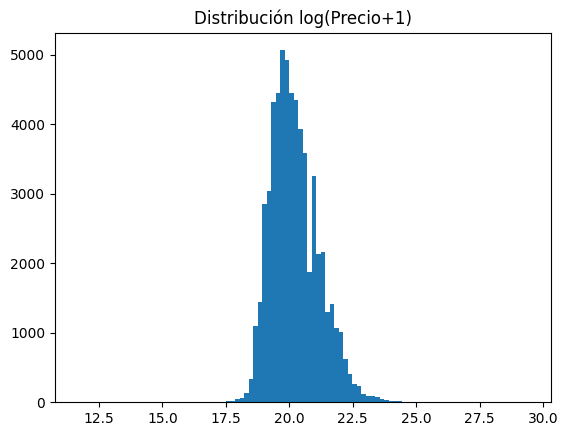

In [29]:
import matplotlib.pyplot as plt, numpy as np
plt.hist(np.log1p(df_full['Precio']), bins=100)
plt.title("Distribución log(Precio+1)")


In [42]:
# ---------------------------------------------------------------------
# 6. PICK BEST AND SAVE -----------------------------------------------
# ---------------------------------------------------------------------
best = min(results, key=lambda d: d["rmse_eur"])
print(f"\n🏆  Mejor modelo: {best['name']}  (RMSE€ {best['rmse_eur']:,.0f})")


🏆  Mejor modelo: LightGBM  (RMSE€ 776,296,981)


In [ ]:

model_path = f"models/{best['name'].lower()}_logprice.joblib"
joblib.dump(best["model"], model_path)
print(f"📦  Modelo guardado en {model_path}")
